<a href="https://colab.research.google.com/github/VISHWAJA-028/ML_Multimodality/blob/main/ML_unstructred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve, ConfusionMatrixDisplay)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (16).zip to archive (16).zip


In [3]:
# ==========================================
# CELL 4: EXTRACT DATASET
# ==========================================

import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
DATA_ROOT = '/content/dataset'

In [5]:
DATA_ROOT = '/content/dataset/train'

In [6]:
DATA_ROOT = '/content/dataset/archive (7)'

In [7]:
DATA_ROOT = '/content/dataset/archive (7)/PCOS'

In [16]:
import os

DATA_ROOT = '/content/dataset/archive (7)/PCOS'

print("Contents:", os.listdir(DATA_ROOT))

Contents: ['infected', 'noninfected']


In [8]:
# ==========================================
# CELL 6: IMAGE SETTINGS
# ==========================================

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

CLASS_NAMES = [
    'noninfected',
    'infected'
]

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASS_NAMES)

Image size: (224, 224)
Batch size: 32
Classes: ['noninfected', 'infected']


In [9]:
# Count images in each class

image_extensions = (
    '.jpg',
    '.jpeg',
    '.png',
    '.bmp',
    '.webp'
)

for class_name in CLASS_NAMES:

    class_path = os.path.join(
        DATA_ROOT,
        class_name
    )

    count = sum(
        f.lower().endswith(image_extensions)
        for f in os.listdir(class_path)
    )

    print(
        class_name,
        "images:",
        count
    )

noninfected images: 5000
infected images: 6784


In [11]:
# ==========================================
# CELL 7: LOAD DATASET
# ==========================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    DATA_ROOT,

    validation_split=0.30,

    subset='training',

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_names=CLASS_NAMES,

    shuffle=True
)


holdout_ds = tf.keras.utils.image_dataset_from_directory(

    DATA_ROOT,

    validation_split=0.30,

    subset='validation',

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_names=CLASS_NAMES,

    shuffle=False
)

Found 11784 files belonging to 2 classes.
Using 8249 files for training.
Found 11784 files belonging to 2 classes.
Using 3535 files for validation.


In [12]:
# ==========================================
# CELL 8: VALIDATION + TEST SPLIT
# ==========================================

holdout_batches = (
    tf.data.experimental
    .cardinality(holdout_ds)
    .numpy()
)

val_batches = holdout_batches // 2

val_ds = holdout_ds.take(val_batches)

test_ds = holdout_ds.skip(val_batches)

print("Training batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(val_ds).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 258
Validation batches: 55
Test batches: 56


In [13]:
# ==========================================
# CELL 9: PERFORMANCE OPTIMIZATION
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

print("Cache and prefetch configured.")

Cache and prefetch configured.


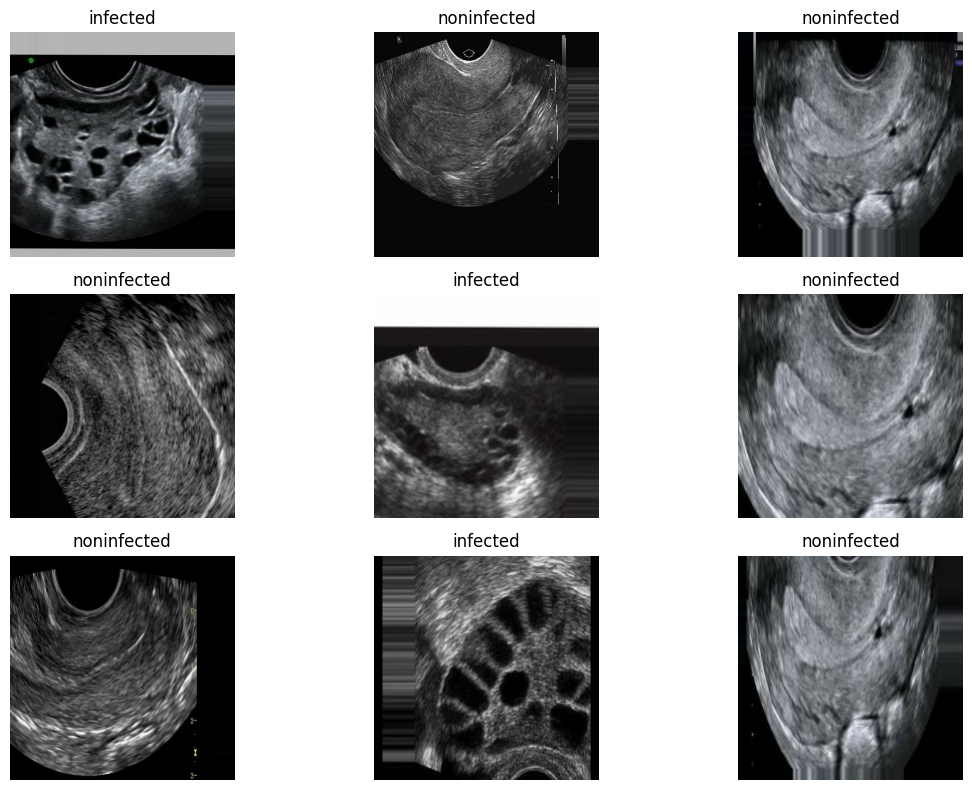

In [14]:
# ==========================================
# CELL 10: SAMPLE IMAGES
# ==========================================

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype('uint8')
        )

        plt.title(
            CLASS_NAMES[labels[i].numpy()]
        )

        plt.axis('off')

plt.tight_layout()
plt.show()

Image counts: {'noninfected': 5000, 'infected': 6784}


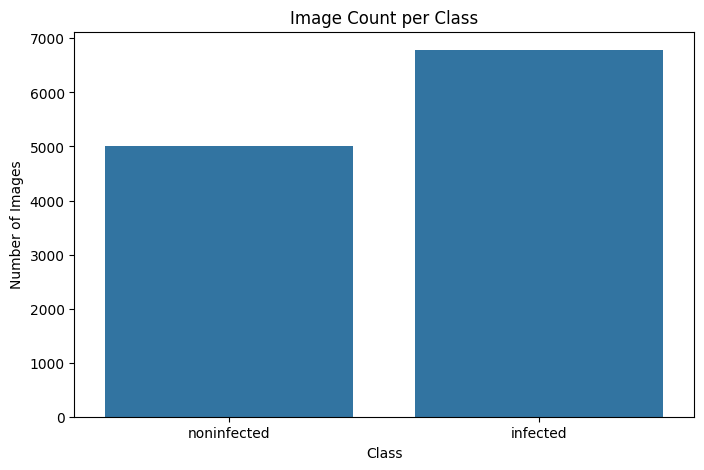

In [15]:
# ==========================================
# CELL 11: CLASS BALANCE
# ==========================================

counts = {}

for class_name in CLASS_NAMES:

    class_path = os.path.join(
        DATA_ROOT,
        class_name
    )

    counts[class_name] = sum(
        f.lower().endswith(image_extensions)
        for f in os.listdir(class_path)
    )

print("Image counts:", counts)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=list(counts.keys()),
    y=list(counts.values())
)

plt.title("Image Count per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [17]:
# ==========================================
# CELL 12: DATA AUGMENTATION
# ==========================================

data_augmentation = keras.Sequential([

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.1),

    layers.RandomContrast(0.1)

], name="augmentation")

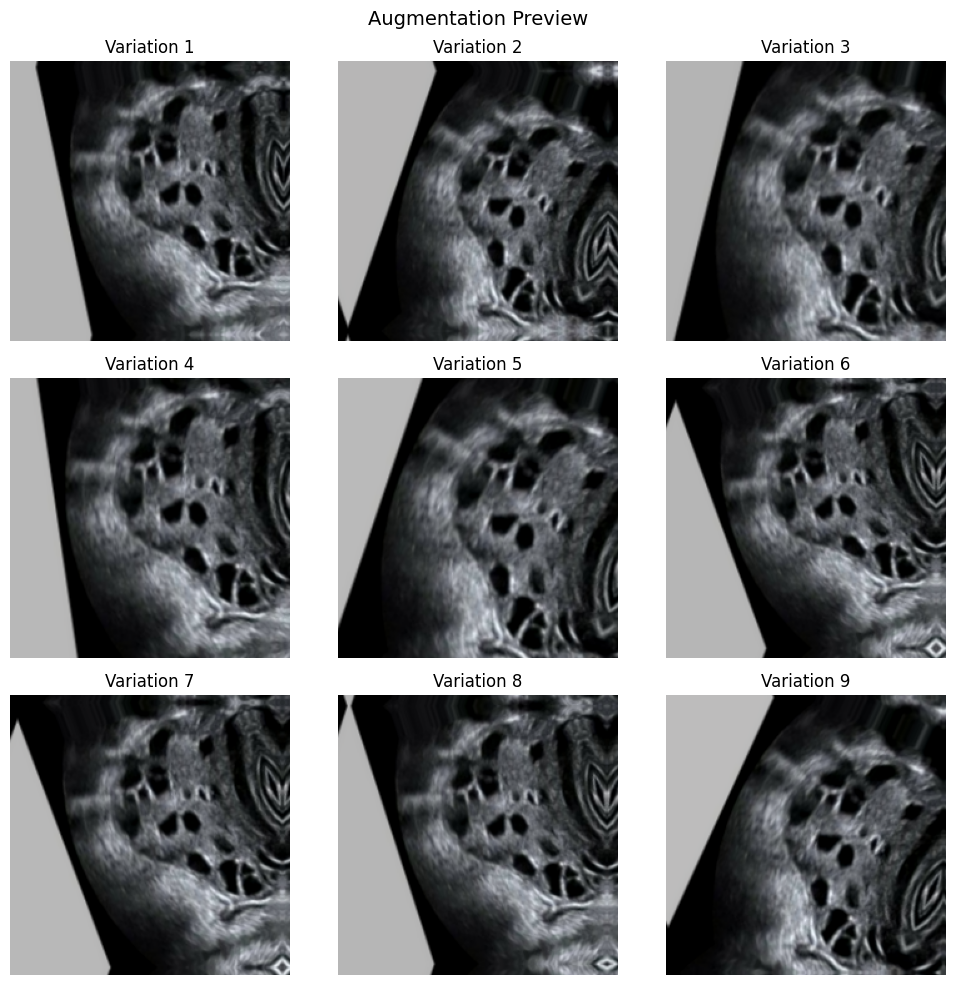

In [18]:
# ==========================================
# CELL 13: AUGMENTATION PREVIEW
# ==========================================

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    original_image = images[0]

    for i in range(9):

        image = tf.expand_dims(
            original_image,
            axis=0
        )

        augmented_image = data_augmentation(
            image,
            training=True
        )

        augmented_image = tf.squeeze(
            augmented_image,
            axis=0
        )

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.clip_by_value(
                augmented_image,
                0,
                255
            ).numpy().astype("uint8")
        )

        plt.axis("off")

        plt.title(
            f"Variation {i + 1}"
        )

plt.suptitle(
    "Augmentation Preview",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# CELL 14: PRETRAINED MODELS
# ==========================================

from tensorflow.keras.applications import (
    ResNet50,
    MobileNetV2,
    EfficientNetB0
)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)

from tensorflow.keras.applications.efficientnet import (
    preprocess_input as efficientnet_preprocess
)

In [21]:
# ==========================================
# CELL 15: MODEL ARCHITECTURES
# ==========================================

ARCHITECTURES = {

    'ResNet50': (
        ResNet50,
        resnet_preprocess
    ),

    'MobileNetV2': (
        MobileNetV2,
        mobilenet_preprocess
    ),

    'EfficientNetB0': (
        EfficientNetB0,
        efficientnet_preprocess
    )
}

print("Models to compare:")

for name in ARCHITECTURES:
    print("-", name)

Models to compare:
- ResNet50
- MobileNetV2
- EfficientNetB0


In [22]:
# ==========================================
# CELL 16: BUILD TRANSFER LEARNING MODEL
# ==========================================

def build_model(
    base_class,
    preprocess_fn
):

    # --------------------------------------
    # Load pretrained backbone
    # --------------------------------------

    base = base_class(

        weights='imagenet',

        include_top=False,

        input_shape=IMG_SIZE + (3,)
    )

    # Freeze backbone
    base.trainable = False

    # --------------------------------------
    # Input
    # --------------------------------------

    inputs = keras.Input(
        shape=IMG_SIZE + (3,)
    )

    # --------------------------------------
    # Data augmentation
    # --------------------------------------

    x = data_augmentation(
        inputs
    )

    # --------------------------------------
    # Preprocessing
    # --------------------------------------

    x = preprocess_fn(x)

    # --------------------------------------
    # Pretrained CNN
    # --------------------------------------

    x = base(
        x,
        training=False
    )

    # --------------------------------------
    # Classification head
    # --------------------------------------

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)

    x = layers.Dense(
        64,
        activation='relu'
    )(x)

    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(
        1,
        activation='sigmoid'
    )(x)

    # --------------------------------------
    # Create model
    # --------------------------------------

    model = keras.Model(
        inputs,
        outputs
    )

    # --------------------------------------
    # Compile
    # --------------------------------------

    model.compile(

        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),

        loss='binary_crossentropy',

        metrics=[
            'accuracy',
            keras.metrics.AUC(
                name='auc'
            )
        ]
    )

    return model, base

In [23]:
# ==========================================
# CELL 17: MODEL COMPARISON
# ==========================================

COMPARISON_EPOCHS = 2

comparison_results = {}

trained_models = {}

for name, (
    base_class,
    preprocess_fn
) in ARCHITECTURES.items():

    print("\n")
    print("=" * 60)
    print(f"TRAINING: {name}")
    print("=" * 60)

    # Build model
    model, base = build_model(
        base_class,
        preprocess_fn
    )

    # Train
    history = model.fit(

        train_ds,

        validation_data=val_ds,

        epochs=COMPARISON_EPOCHS,

        verbose=1
    )

    # --------------------------------------
    # Validation predictions
    # --------------------------------------

    val_probs = model.predict(
        val_ds,
        verbose=0
    ).ravel()

    # --------------------------------------
    # Validation labels
    # --------------------------------------

    val_labels = np.concatenate([

        labels.numpy()

        for images, labels in val_ds

    ])

    # --------------------------------------
    # Convert probability to class
    # --------------------------------------

    val_preds = (
        val_probs >= 0.5
    ).astype(int)

    # --------------------------------------
    # Metrics
    # --------------------------------------

    accuracy = accuracy_score(
        val_labels,
        val_preds
    )

    precision = precision_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    recall = recall_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    f1 = f1_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    auc = roc_auc_score(
        val_labels,
        val_probs
    )

    # --------------------------------------
    # Store results
    # --------------------------------------

    comparison_results[name] = {

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1-Score': f1,

        'AUC': auc
    }

    # Save model
    trained_models[name] = (
        model,
        base,
        preprocess_fn
    )

    print(f"\n{name} Results")

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1-Score : {f1:.4f}"
    )

    print(
        f"AUC      : {auc:.4f}"
    )



TRAINING: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 65s 181ms/step - accuracy: 0.9297 - auc: 0.9820 - loss: 0.1698 - val_accuracy: 0.8557 - val_auc: 0.0000e+00 - val_loss: 0.3246
Epoch 2/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 75s 177ms/step - accuracy: 0.9618 - auc: 0.9938 - loss: 0.0967 - val_accuracy: 0.9085 - val_auc: 0.0000e+00 - val_loss: 0.1857


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



ResNet50 Results
Accuracy : 0.9085
Precision: 1.0000
Recall   : 0.9085
F1-Score : 0.9521
AUC      : nan


TRAINING: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step - accuracy: 0.9324 - auc: 0.9835 - loss: 0.1607 - val_accuracy: 0.8903 - val_auc: 0.0000e+00 - val_loss: 0.2728
Epoch 2/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.9606 - auc: 0.9932 - loss: 0.1002 - val_accuracy: 0.8398 - val_auc: 0.0000e+00 - val_loss: 0.5346


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



MobileNetV2 Results
Accuracy : 0.8398
Precision: 1.0000
Recall   : 0.8398
F1-Score : 0.9129
AUC      : nan


TRAINING: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - accuracy: 0.9366 - auc: 0.9860 - loss: 0.1505 - val_accuracy: 0.8938 - val_auc: 0.0000e+00 - val_loss: 0.2752
Epoch 2/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.9593 - auc: 0.9939 - loss: 0.0975 - val_accuracy: 0.9244 - val_auc: 0.0000e+00 - val_loss: 0.2297

EfficientNetB0 Results
Accuracy : 0.9244
Precision: 1.0000
Recall   : 0.9244
F1-Score : 0.9607
AUC      : nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [26]:
import pandas as pd

# ==========================================
# CELL 18: COMPARISON TABLE
# ==========================================

comparison_df = pd.DataFrame(
    comparison_results
).T

comparison_df = comparison_df.sort_values(
    by='AUC',
    ascending=False
)

print("FINAL MODEL COMPARISON")

display(
    comparison_df.round(4)
)

FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1-Score,AUC
ResNet50,0.9085,1.0,0.9085,0.9521,NaN
MobileNetV2,0.8398,1.0,0.8398,0.9129,NaN
EfficientNetB0,0.9244,1.0,0.9244,0.9607,NaN


In [27]:
# ==========================================
# CELL 19: SELECT BEST MODEL
# ==========================================

best_model_name = comparison_df.index[0]

print(
    "Best model:",
    best_model_name
)

Best model: ResNet50


In [28]:
# ==========================================
# CELL 20: GET BEST MODEL
# ==========================================

best_model, base_model, preprocess_fn = trained_models[
    best_model_name
]

print(
    "Selected model:",
    best_model_name
)

Selected model: ResNet50


In [29]:
# ==========================================
# CELL 21: FINE-TUNING
# ==========================================

base_model.trainable = True

# Freeze earlier layers
for layer in base_model.layers[:-30]:

    layer.trainable = False

# Keep BatchNormalization frozen
for layer in base_model.layers:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

print(
    "Trainable layers:",
    sum(
        layer.trainable
        for layer in base_model.layers
    )
)

Trainable layers: 21


In [30]:
# ==========================================
# CELL 22: RECOMPILE FOR FINE-TUNING
# ==========================================

best_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',

        keras.metrics.Precision(
            name='precision'
        ),

        keras.metrics.Recall(
            name='recall'
        ),

        keras.metrics.AUC(
            name='auc'
        )
    ]
)

In [31]:
# ==========================================
# CELL 23: FINE-TUNE BEST MODEL
# ==========================================

FINE_TUNE_EPOCHS = 10

fine_tune_history = best_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=FINE_TUNE_EPOCHS,

    verbose=1
)

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 71s 233ms/step - accuracy: 0.9747 - auc: 0.9964 - loss: 0.0705 - precision: 0.9743 - recall: 0.9815 - val_accuracy: 0.9307 - val_auc: 0.0000e+00 - val_loss: 0.1788 - val_precision: 1.0000 - val_recall: 0.9307
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 56s 217ms/step - accuracy: 0.9793 - auc: 0.9975 - loss: 0.0564 - precision: 0.9785 - recall: 0.9853 - val_accuracy: 0.9131 - val_auc: 0.0000e+00 - val_loss: 0.2511 - val_precision: 1.0000 - val_recall: 0.9131
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 55s 212ms/step - accuracy: 0.9852 - auc: 0.9984 - loss: 0.0452 - precision: 0.9848 - recall: 0.9894 - val_accuracy: 0.8670 - val_auc: 0.0000e+00 - val_loss: 0.6278 - val_precision: 1.0000 - val_recall: 0.8670
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 55s 214ms/step - accuracy: 0.9850 - auc: 0.9986 - loss: 0.0411 - precision: 0.9846 - recall: 0.9892 - val_accuracy: 0.8756 - val_auc: 0.0000e+00 - val_loss: 0.6668 - val_precision: 1.0000 - val_recall: 0.8756
Epoc

In [32]:
# ==========================================
# CELL 24: FINAL TEST EVALUATION
# ==========================================

test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFINAL TEST RESULTS")
print("=" * 50)

for metric_name, value in zip(
    best_model.metrics_names,
    test_results
):

    print(
        f"{metric_name}: {value:.4f}"
    )

56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.3842 - auc: 0.0000e+00 - loss: 3.3376 - precision: 1.0000 - recall: 0.3842

FINAL TEST RESULTS
loss: 3.3376
compile_metrics: 0.3842


In [33]:
# ==========================================
# CELL 25: TEST PREDICTIONS
# ==========================================

test_probs = best_model.predict(
    test_ds,
    verbose=0
).ravel()

test_labels = np.concatenate([

    labels.numpy()

    for images, labels in test_ds

])

test_preds = (
    test_probs >= 0.5
).astype(int)

print(
    "Number of test images:",
    len(test_labels)
)

Number of test images: 1775


In [34]:
# ==========================================
# CELL 26: FINAL METRICS
# ==========================================

final_accuracy = accuracy_score(
    test_labels,
    test_preds
)

final_precision = precision_score(
    test_labels,
    test_preds,
    zero_division=0
)

final_recall = recall_score(
    test_labels,
    test_preds,
    zero_division=0
)

final_f1 = f1_score(
    test_labels,
    test_preds,
    zero_division=0
)

final_auc = roc_auc_score(
    test_labels,
    test_probs
)

print("\nFINAL TEST METRICS")
print("=" * 50)

print(
    f"Accuracy : {final_accuracy:.4f}"
)

print(
    f"Precision: {final_precision:.4f}"
)

print(
    f"Recall   : {final_recall:.4f}"
)

print(
    f"F1-Score : {final_f1:.4f}"
)

print(
    f"ROC-AUC  : {final_auc:.4f}"
)


FINAL TEST METRICS
Accuracy : 0.3842
Precision: 1.0000
Recall   : 0.3842
F1-Score : 0.5551
ROC-AUC  : nan


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


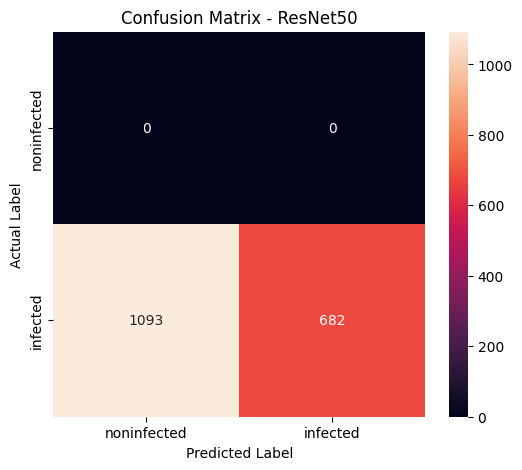

In [35]:
# ==========================================
# CELL 27: CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

In [36]:
# ==========================================
# CELL 28: CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(

        test_labels,

        test_preds,

        target_names=CLASS_NAMES,

        digits=4
    )
)

              precision    recall  f1-score   support

 noninfected     0.0000    0.0000    0.0000         0
    infected     1.0000    0.3842    0.5551      1775

    accuracy                         0.3842      1775
   macro avg     0.5000    0.1921    0.2776      1775
weighted avg     1.0000    0.3842    0.5551      1775



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


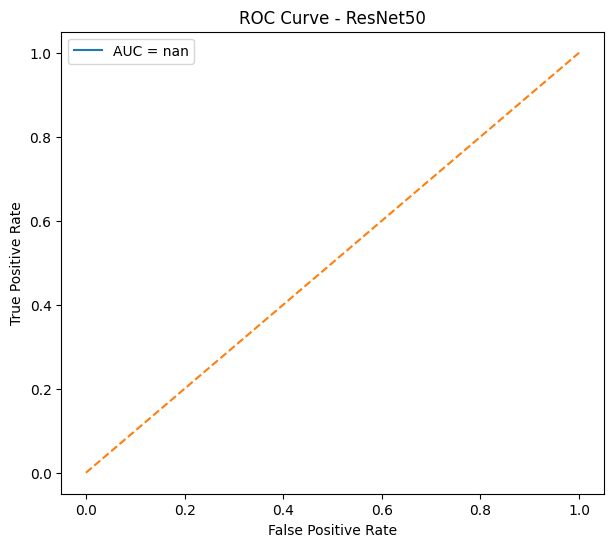

In [37]:
# ==========================================
# CELL 29: ROC CURVE
# ==========================================

fpr, tpr, thresholds = roc_curve(
    test_labels,
    test_probs
)

roc_auc_value = roc_auc_score(
    test_labels,
    test_probs
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc_value:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend()

plt.show()

In [38]:
# ==========================================
# CELL 30: SAVE FINAL MODEL
# ==========================================

MODEL_PATH = (
    '/content/PCOS_best_image_model.keras'
)

best_model.save(
    MODEL_PATH
)

print(
    "Final model saved at:",
    MODEL_PATH
)

Final model saved at: /content/PCOS_best_image_model.keras


In [39]:
# ==========================================
# CELL 31: SAVE MODEL INFORMATION
# ==========================================

model_info = {

    "best_model": best_model_name,

    "class_names": CLASS_NAMES,

    "image_size": list(IMG_SIZE),

    "threshold": 0.5,

    "accuracy": float(final_accuracy),

    "precision": float(final_precision),

    "recall": float(final_recall),

    "f1_score": float(final_f1),

    "roc_auc": float(final_auc)
}

INFO_PATH = (
    '/content/PCOS_image_model_info.json'
)

with open(
    INFO_PATH,
    'w'
) as f:

    json.dump(
        model_info,
        f,
        indent=4
    )

print(
    "Model information saved at:",
    INFO_PATH
)

Model information saved at: /content/PCOS_image_model_info.json
